# Notebook 2 — Meridian MMM Model

Fits a Bayesian Marketing Mix Model using Google's Meridian library on the synthetic data from Notebook 1.

**Run Notebook 1 first** to generate `data/synthetic_mmm.csv`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import meridian
from meridian.data import input_data as input_data_lib
from meridian.model import model as meridian_model   # meridian.model.model, not .meridian
from meridian.model import spec
from meridian.analysis import optimizer, analyzer

sns.set_theme(style='whitegrid')
%matplotlib inline

print('Meridian version:', meridian.__version__)

Meridian version: 1.7.0


## 1. Load data & build xarray InputData

In [2]:
df = pd.read_csv('../data/synthetic_mmm.csv', parse_dates=['date'])

GEO            = 'national'
MEDIA_CHANNELS = ['tv', 'search', 'social', 'display']
SPEND_COLS     = ['tv_spend', 'search_spend', 'social_spend', 'display_spend']
COLORS         = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
N_WEEKS        = len(df)

# Meridian requires time coords as 'YYYY-MM-DD' strings
TIME_COORDS = df['date'].dt.strftime('%Y-%m-%d').tolist()

kpi = xr.DataArray(
    data=df['revenue'].values[np.newaxis, :],
    dims=['geo', 'time'],
    coords={'geo': [GEO], 'time': TIME_COORDS},
    name='kpi',
)

population = xr.DataArray(
    data=np.array([1.0]),
    dims=['geo'],
    coords={'geo': [GEO]},
    name='population',
)

# media_spend: dims (geo, time, media_channel) — raw £ spend
media_spend = xr.DataArray(
    data=df[SPEND_COLS].values[np.newaxis, :, :],
    dims=['geo', 'time', 'media_channel'],
    coords={'geo': [GEO], 'time': TIME_COORDS, 'media_channel': MEDIA_CHANNELS},
    name='media_spend',
)

# media: dims (geo, media_time, media_channel) — normalised impressions proxy
media_impressions = xr.DataArray(
    data=(df[SPEND_COLS].values / df[SPEND_COLS].values.max(axis=0))[np.newaxis, :, :],
    dims=['geo', 'media_time', 'media_channel'],
    coords={'geo': [GEO], 'media_time': TIME_COORDS, 'media_channel': MEDIA_CHANNELS},
    name='media',
)

input_data = input_data_lib.InputData(
    kpi=kpi,
    kpi_type='revenue',
    population=population,
    media=media_impressions,
    media_spend=media_spend,
)

print('InputData created successfully')
print('KPI shape:   ', kpi.shape)
print('Media shape: ', media_impressions.shape)
print('Spend shape: ', media_spend.shape)

InputData created successfully
KPI shape:    (1, 104)
Media shape:  (1, 104, 4)
Spend shape:  (1, 104, 4)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/data/input_data.py:517: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


## 2. Define ModelSpec & fit

In [3]:
model_spec = spec.ModelSpec(
    # Hill saturation priors (ec = half-saturation, slope = shape)
    hill_before_adstock=False,   # adstock first, then saturation
    # Adstock / lag priors use defaults
)

mmm = meridian_model.Meridian(input_data=input_data, model_spec=model_spec)

I0000 00:00:1782214133.687508 6309997 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


In [4]:
# Sample prior first (required by hill_curves and other diagnostics)
mmm.sample_prior(n_draws=500, seed=42)
print('Prior sampling complete.')

# MCMC posterior — fewer draws for speed; increase n_keep for production
mmm.sample_posterior(
    n_chains=2,
    n_adapt=500,
    n_burnin=500,
    n_keep=1000,
    seed=42,
)
print('Posterior sampling complete.')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/meridian/model/pr

Prior sampling complete.


2026-06-23 12:29:21.164810: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Posterior sampling complete.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


## 3. Model diagnostics

In [5]:
an = analyzer.Analyzer(mmm)

# R-hat: want all values < 1.05 for good convergence
rhat = an.get_rhat()  # returns Mapping[str, tensor]
rhat_vals = {k: float(v.numpy().max()) for k, v in rhat.items()}
max_rhat = max(rhat_vals.values())
print(f'Max R-hat across all params: {max_rhat:.4f}  (target < 1.05)')
pd.Series(rhat_vals, name='max_rhat').sort_values(ascending=False).head(10)

Max R-hat across all params: 1.0041  (target < 1.05)


/var/folders/zy/0yc78h6x5xq7w_xzp3jlfvzr0000gn/T/ipykernel_16429/3478180520.py:1: DeprecationWarning: The `meridian` argument is deprecated and will be removed in a future version. Use `model_context` instead.
  an = analyzer.Analyzer(mmm)


roi_m          1.004073
knot_values    1.003466
mu_t           1.003466
ec_m           1.002695
alpha_m        1.002482
beta_gm        1.001729
beta_m         1.001729
sigma          0.999247
eta_m               NaN
slope_m             NaN
Name: max_rhat, dtype: float64

expected_outcome shape: (2, 1000, 104)


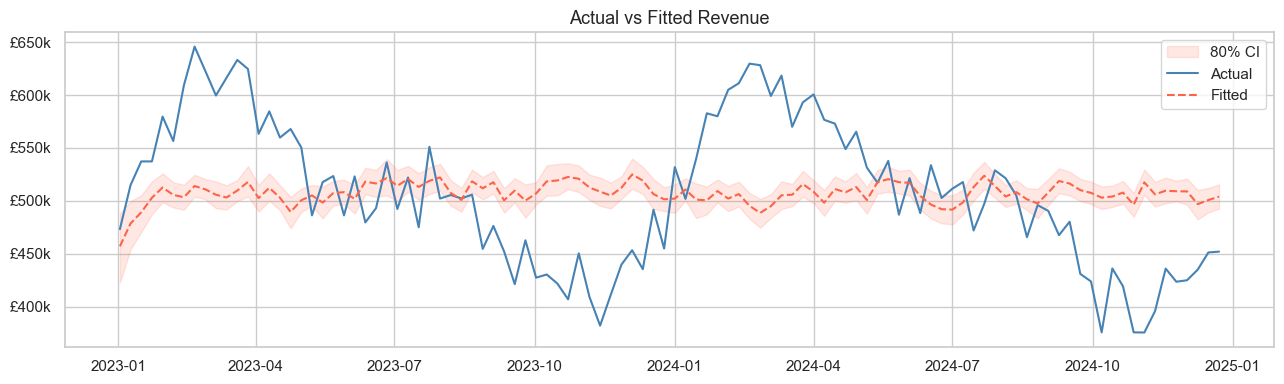

R²: 0.018   MAPE: 11.8%


In [6]:
# expected_outcome returns a tensor of shape (n_chains, n_keep, n_time) or (n_samples, n_time)
outcome    = an.expected_outcome(use_posterior=True, aggregate_times=False)
outcome_np = outcome.numpy()
print('expected_outcome shape:', outcome_np.shape)

# Flatten all sample dims → (n_samples, n_time)
outcome_flat = outcome_np.reshape(-1, N_WEEKS)
pred_mean = outcome_flat.mean(axis=0)
pred_lo   = np.quantile(outcome_flat, 0.1, axis=0)
pred_hi   = np.quantile(outcome_flat, 0.9, axis=0)
actual    = df['revenue'].values

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(df['date'], pred_lo, pred_hi, alpha=0.15, color='tomato', label='80% CI')
ax.plot(df['date'], actual,    label='Actual', color='steelblue', linewidth=1.5)
ax.plot(df['date'], pred_mean, label='Fitted', color='tomato',    linewidth=1.5, linestyle='--')
ax.set_title('Actual vs Fitted Revenue', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
plt.tight_layout()
plt.savefig('../outputs/actual_vs_fitted.png', dpi=150)
plt.show()

r2   = float(np.corrcoef(actual, pred_mean)[0, 1] ** 2)
mape = float(np.mean(np.abs((actual - pred_mean) / actual)) * 100)
print(f'R²: {r2:.3f}   MAPE: {mape:.1f}%')

## 4. Channel ROI & contribution

roi shape: (2, 1000, 4)


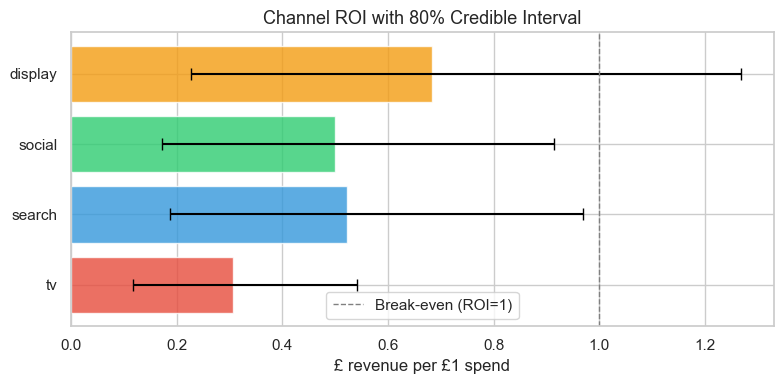

,channel,roi_mean,roi_lo,roi_hi
0,tv,0.31,0.12,0.54
1,search,0.52,0.19,0.97
2,social,0.50,0.17,0.91
3,display,0.68,0.23,1.27


In [7]:
# roi() returns tensor — shape may be (n_chains, n_keep, n_channels) or (n_samples, n_channels)
roi_tensor = an.roi(use_posterior=True)
roi_np     = roi_tensor.numpy()
print('roi shape:', roi_np.shape)

# Flatten sample dims → (n_samples, n_channels)
roi_flat = roi_np.reshape(-1, len(MEDIA_CHANNELS))

roi_df = pd.DataFrame({
    'channel':  MEDIA_CHANNELS,
    'roi_mean': roi_flat.mean(axis=0),
    'roi_lo':   np.quantile(roi_flat, 0.1, axis=0),
    'roi_hi':   np.quantile(roi_flat, 0.9, axis=0),
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(roi_df['channel'], roi_df['roi_mean'], color=COLORS, alpha=0.8)
ax.errorbar(
    roi_df['roi_mean'], roi_df['channel'],
    xerr=[roi_df['roi_mean'] - roi_df['roi_lo'],
          roi_df['roi_hi']   - roi_df['roi_mean']],
    fmt='none', color='black', capsize=4,
)
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1, label='Break-even (ROI=1)')
ax.set_title('Channel ROI with 80% Credible Interval', fontsize=13)
ax.set_xlabel('£ revenue per £1 spend')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/channel_roi.png', dpi=150)
plt.show()

roi_df.round(2)

## 5. Revenue decomposition (waterfall)

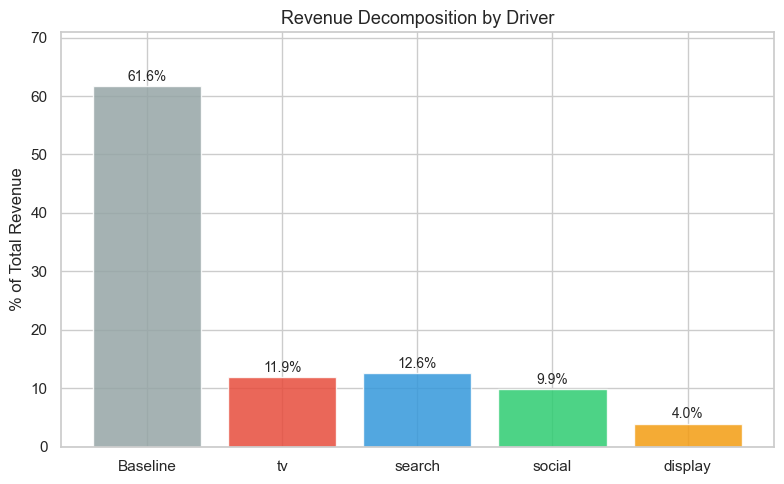

In [8]:
# Decomposition: incremental contribution per channel = mean ROI × total spend
# Baseline = total revenue − sum of channel contributions
total_spend_per_channel = df[SPEND_COLS].sum().values
incremental_per_channel = roi_df['roi_mean'].values * total_spend_per_channel
total_revenue           = df['revenue'].sum()
baseline                = total_revenue - incremental_per_channel.sum()

labels     = ['Baseline'] + MEDIA_CHANNELS
values     = np.array([baseline] + list(incremental_per_channel))
shares     = values / values.sum() * 100
bar_colors = ['#95a5a6'] + COLORS

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, shares, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, s in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{s:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Revenue Decomposition by Driver', fontsize=13)
ax.set_ylabel('% of Total Revenue')
ax.set_ylim(0, max(shares) * 1.15)
plt.tight_layout()
plt.savefig('../outputs/revenue_decomposition.png', dpi=150)
plt.show()

## 6. Response curves

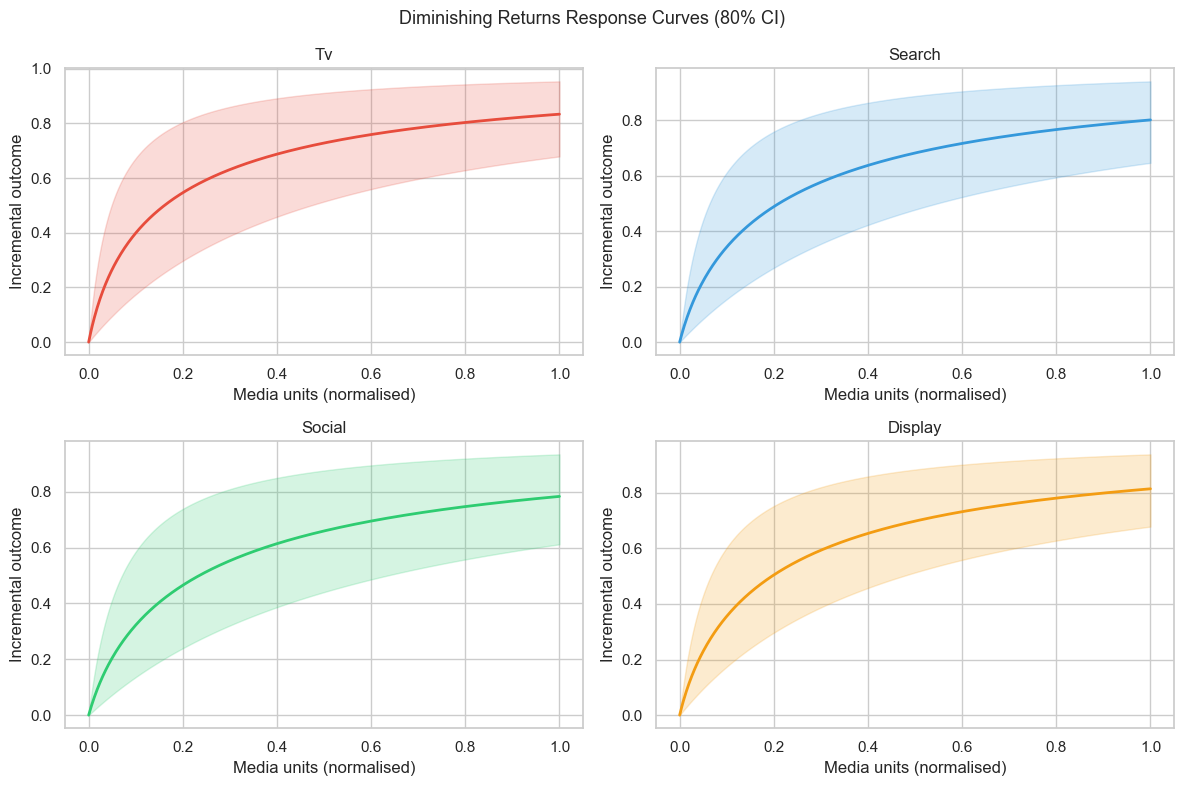

In [9]:
# hill_curves() columns: channel, media_units, distribution, ci_hi, ci_lo, mean
curves_df = an.hill_curves(n_bins=50, confidence_level=0.8)
posterior_curves = curves_df[curves_df['distribution'] == 'posterior']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, channel, color in zip(axes.flat, MEDIA_CHANNELS, COLORS):
    ch = posterior_curves[posterior_curves['channel'] == channel].dropna(subset=['mean'])
    ax.fill_between(ch['media_units'], ch['ci_lo'], ch['ci_hi'], alpha=0.2, color=color)
    ax.plot(ch['media_units'], ch['mean'], color=color, linewidth=2)
    ax.set_title(channel.title(), fontsize=12)
    ax.set_xlabel('Media units (normalised)')
    ax.set_ylabel('Incremental outcome')

fig.suptitle('Diminishing Returns Response Curves (80% CI)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/response_curves.png', dpi=150)
plt.show()

## 7. Budget optimisation

Given the same total budget, find the spend allocation that maximises revenue.

optimized_data vars: ['spend', 'pct_of_spend', 'incremental_outcome', 'effectiveness', 'roi', 'mroi', 'cpik']
optimized_data dims: {'channel': 4, 'metric': 4}
opt_spend shape: () values: 11665.0


/var/folders/zy/0yc78h6x5xq7w_xzp3jlfvzr0000gn/T/ipykernel_16429/678920925.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('optimized_data dims:', dict(opt_data.dims))


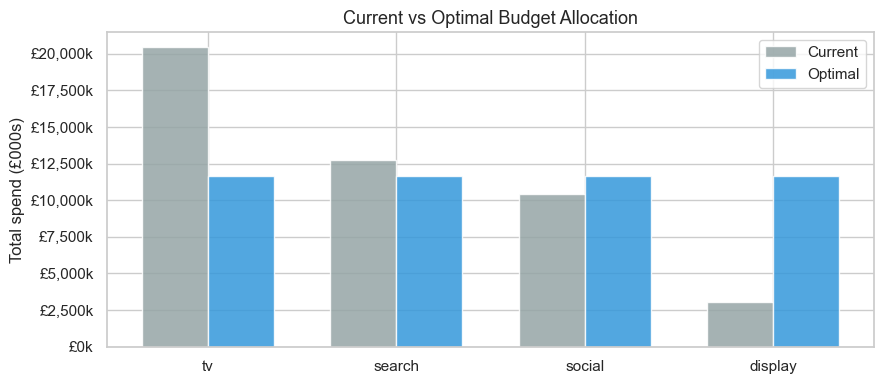

,channel,current,optimal,change,change_pct
0,tv,20427.4,11665.0,-8762.4,-42.9
1,search,12726.5,11665.0,-1061.5,-8.3
2,social,10416.4,11665.0,1248.6,12.0
3,display,3079.0,11665.0,8586.0,278.9


In [10]:
total_budget = float(df[SPEND_COLS].sum().sum())

opt    = optimizer.BudgetOptimizer(mmm)
result = opt.optimize(budget=total_budget, use_posterior=True, fixed_budget=True)

# Inspect what's available in optimized_data
opt_data    = result.optimized_data
nonopt_data = result.nonoptimized_data
print('optimized_data vars:', list(opt_data.data_vars))
print('optimized_data dims:', dict(opt_data.dims))

# Extract spend — variable name may differ across versions
spend_var  = 'spend' if 'spend' in opt_data else list(opt_data.data_vars)[0]
opt_spend  = opt_data[spend_var].mean(dim=[d for d in opt_data[spend_var].dims if d not in ('media_channel',)]).values
print('opt_spend shape:', opt_spend.shape, 'values:', opt_spend)

current_spend = df[SPEND_COLS].sum().values

opt_df = pd.DataFrame({
    'channel':    MEDIA_CHANNELS,
    'current':    current_spend,
    'optimal':    opt_spend,
    'change':     opt_spend - current_spend,
    'change_pct': (opt_spend - current_spend) / current_spend * 100,
})

fig, ax = plt.subplots(figsize=(9, 4))
x, w = np.arange(len(MEDIA_CHANNELS)), 0.35
ax.bar(x - w/2, opt_df['current'], w, label='Current', color='#95a5a6', alpha=0.85)
ax.bar(x + w/2, opt_df['optimal'], w, label='Optimal', color='#3498db', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(MEDIA_CHANNELS)
ax.set_title('Current vs Optimal Budget Allocation', fontsize=13)
ax.set_ylabel('Total spend (£000s)')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
plt.tight_layout()
plt.savefig('../outputs/budget_optimisation.png', dpi=150)
plt.show()

opt_df.round(1)